In [212]:
#import liabary
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib
import calendar

Data Loading

In [213]:
df=pd.read_csv('retail_sales_dataset.csv')
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


EDA- Exploratory Data Analysis

In [214]:
df.shape

(1000, 9)

In [215]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

In [216]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [217]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [218]:
df.dtypes

Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

In [219]:
df.isnull().any()

Transaction ID      False
Date                False
Customer ID         False
Gender              False
Age                 False
Product Category    False
Quantity            False
Price per Unit      False
Total Amount        False
dtype: bool

Checking the missing Value/Nulls

In [220]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Data cleaning by removing duplicates

In [221]:
df.duplicated().sum()

0

Descriptive statistics

In [222]:
df[['Quantity','Price per Unit','Total Amount']].mean()

Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64

In [223]:
df[['Quantity','Price per Unit','Total Amount']].median()

Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64

In [224]:
df[['Quantity','Price per Unit','Total Amount']].mode()

,Quantity,Price per Unit,Total Amount
0,4,50,50


In [225]:
df[['Quantity','Price per Unit','Total Amount']].std()


Quantity            1.132734
Price per Unit    189.681356
Total Amount      559.997632
dtype: float64

Time series analysis/Customer demographics analysis

In [226]:
#changing object into datetime.
df["Date"]=pd.to_datetime(df["Date"])
type(df["Date"][0])

pandas._libs.tslibs.timestamps.Timestamp

In [227]:
df.dtypes

Transaction ID               int64
Date                datetime64[ns]
Customer ID                 object
Gender                      object
Age                          int64
Product Category            object
Quantity                     int64
Price per Unit               int64
Total Amount                 int64
dtype: object

 converting date columns to datetime format).


In [228]:
df['date'] = pd.DatetimeIndex(df['Date']).date
df['year'] = pd.DatetimeIndex(df['Date']).year
df['day'] = pd.DatetimeIndex(df['Date']).day
df['dayofweek'] = pd.DatetimeIndex(df['Date']).dayofweek
df['month'] = pd.DatetimeIndex(df['Date']).month_name()
df['weekday']=pd.DatetimeIndex(df['Date']).day_name()

In [229]:
df['quarter'] = pd.DatetimeIndex(df['Date']).quarter 

In [230]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,date,year,day,dayofweek,month,weekday,quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023-11-24,2023,24,4,November,Friday,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023-02-27,2023,27,0,February,Monday,1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023-01-13,2023,13,4,January,Friday,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023-05-21,2023,21,6,May,Sunday,2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023-05-06,2023,6,5,May,Saturday,2


In [231]:
#Data Visualization
#Let’s start with checking the unique values in dataset of the columns with object datatype.

obj = (df.dtypes == 'object')
object_cols = list(obj[obj].index)
 
unique_values = {}
for col in object_cols:
  unique_values[col] = df[col].unique().size
unique_values

{'Customer ID': 1000,
 'Gender': 2,
 'Product Category': 3,
 'date': 345,
 'month': 12,
 'weekday': 7}

Age Groups

In [232]:
df['Age_Group']=pd.cut(
 df['Age'],
 bins=[0,18,30,45,60,100],
 labels=['Teen','Young','Adult','Adult Senior','Older']
)

In [233]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount,year,day,dayofweek,quarter
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000,2023.002000,15.310000,2.95800,2.525000
std,288.819436,13.68143,1.132734,189.681356,559.997632,0.044699,8.871674,2.02097,1.119208
min,1.000000,18.00000,1.000000,25.000000,25.000000,2023.000000,1.000000,0.00000,1.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000,2023.000000,7.000000,1.00000,2.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000,2023.000000,15.000000,3.00000,2.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000,2023.000000,23.000000,5.00000,4.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000,2024.000000,31.000000,6.00000,4.000000


Customer demographics analysis: distribution of customer age groups, gender breakdown
 (Sales Distribution)

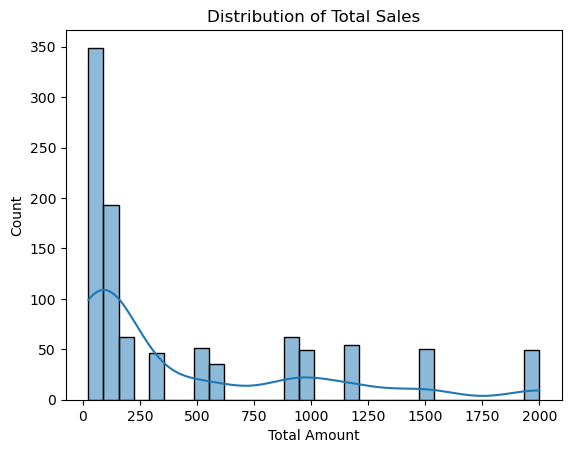

In [234]:
sns.histplot(df['Total Amount'],bins=30,kde=True)
plt.title('Distribution of Total Sales')
plt.show()

Quantity Distribution

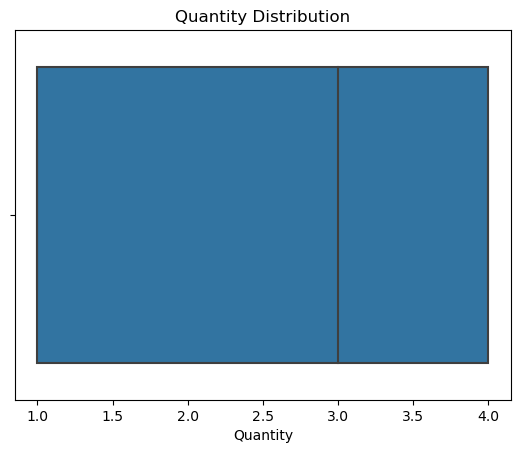

In [235]:
sns.boxplot(x=df['Quantity'])
plt.title('Quantity Distribution')
plt.show()

Quantity vs Total sales

<function matplotlib.pyplot.show(close=None, block=None)>

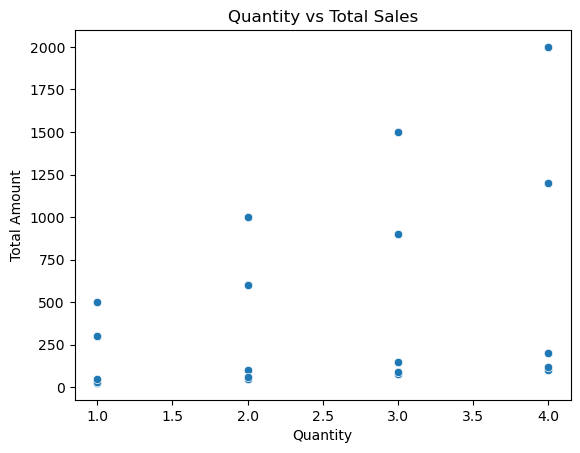

In [236]:
sns.scatterplot(x='Quantity', y='Total Amount', data=df)
plt.title('Quantity vs Total Sales')
plt.show

Gender sales

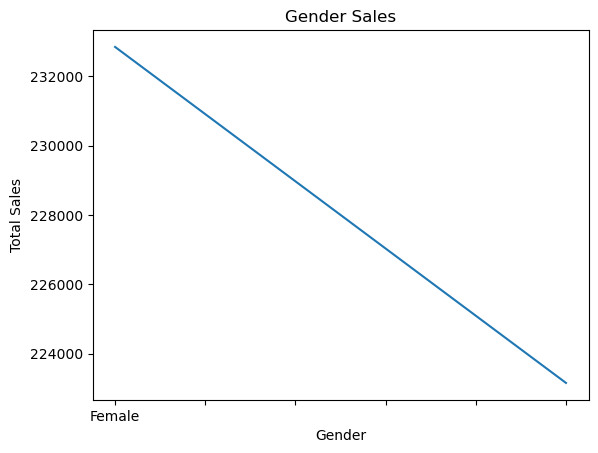

In [237]:
gender_sales=df.groupby('Gender')['Total Amount'].sum()
gender_sales.plot(kind='line')
plt.title('Gender Sales')
plt.ylabel('Total Sales')
plt.show()

Product category

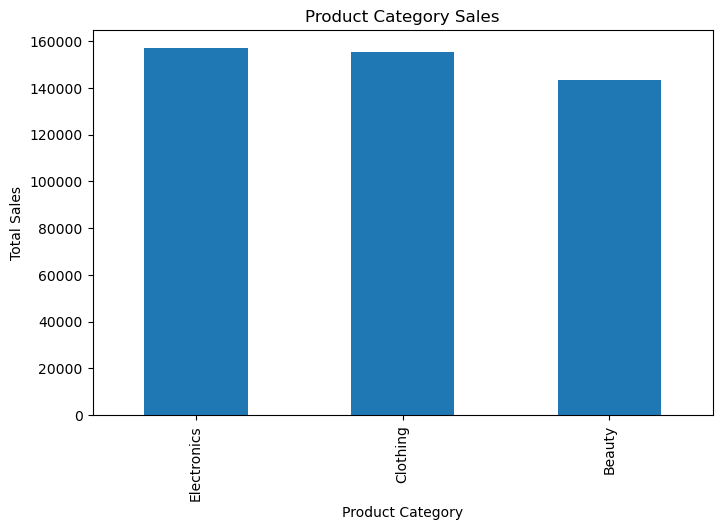

In [238]:
C_Sales=df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)
C_Sales.plot(kind='bar',figsize=(8,5))
plt.title('Product Category Sales')
plt.ylabel('Total Sales')
plt.show()

Customer sale Analysis( Product analysis: top 10 best-selling products; revenue by product category (bar chart)


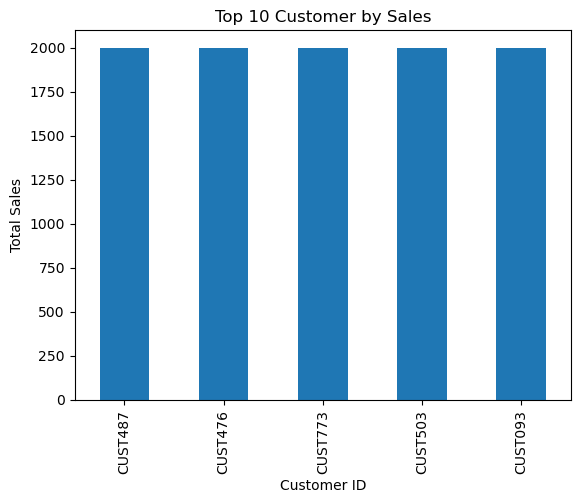

In [252]:
High_customer=df.groupby('Customer ID')['Total Amount'].sum().sort_values(ascending=False).head(5)
High_customer.plot(kind='bar')
plt.title('Top 10 Customer by Sales')
plt.ylabel('Total Sales')
plt.show()

Age Group Sales

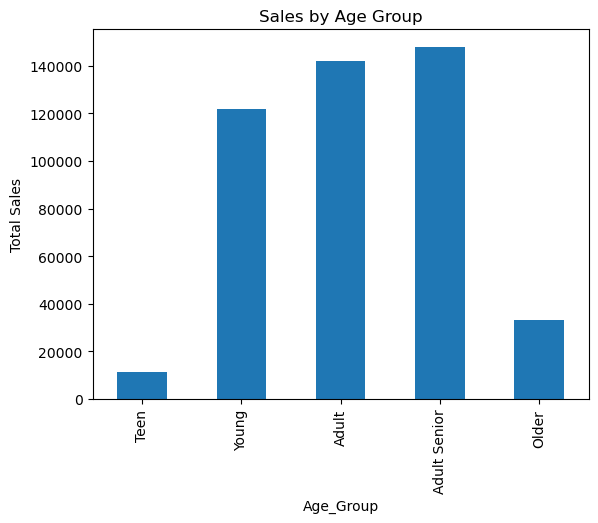

In [240]:
age_group=df.groupby('Age_Group', observed=True)['Total Amount'].sum()
age_group.plot(kind='bar')
plt.title('Sales by Age Group')
plt.ylabel('Total Sales')
plt.show()

Time series Analysis

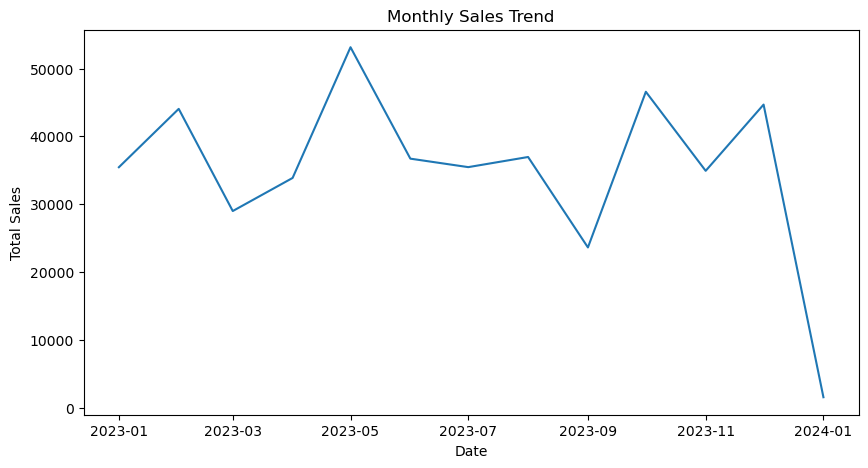

In [241]:
Monthly_sales=df.groupby(df['Date'].dt.to_period('m'))['Total Amount'].sum()
Monthly_sales.index=Monthly_sales.index.to_timestamp()
plt.figure(figsize=(10,5))
plt.plot(Monthly_sales)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()


Heatmap: correlation matrix between numerical variables


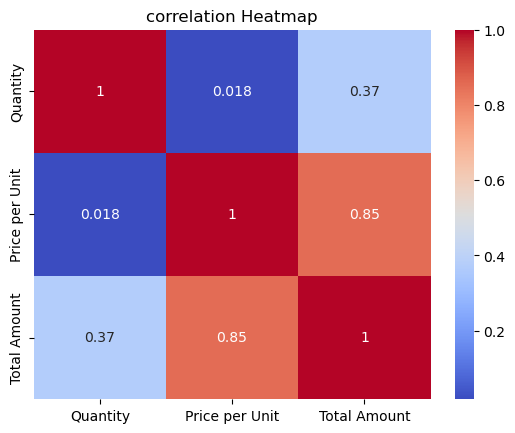

In [242]:
sns.heatmap(
 df[['Quantity','Price per Unit','Total Amount']].corr(),
annot=True,
cmap='coolwarm'
)
plt.title('correlation Heatmap')
plt.show()

<Axes: >

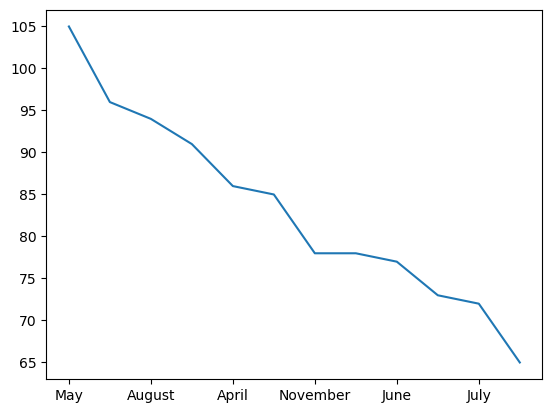

In [247]:
df['month'].value_counts().plot(kind='line')

In [248]:
df['quarter'].value_counts()

2    268
4    265
1    236
3    231
Name: quarter, dtype: int64

<Axes: >

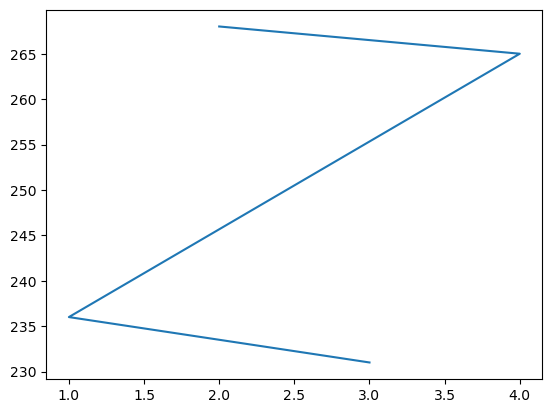

In [249]:
df['quarter'].value_counts().plot(kind='line')

 Markdown cells throughout the notebook with written observations after each chart


In [ ]:
#sales show clear monthly trend
#Quantity strongly impacts total sales
#Adults and young adults are major buyer.

Business recommendations based on findings


In [ ]:
#Focus on repeat customers for loyalty program.
#Target marketing towards high spending age-group.
#put more stock in place for high performing categories.